In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [2]:
SEED = 42
torch.manual_seed(SEED)

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="data", train=False, download=True, transform=transform)
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [4]:
baseline_model = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(16 * 14 * 14, 10)
)

In [5]:
improved_model = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1),
    nn.BatchNorm2d(16),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(16 * 14 * 14, 10)
)

In [6]:
loss_fn = nn.CrossEntropyLoss()

baseline_optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)
improved_optimizer = optim.Adam(improved_model.parameters(), lr=0.001)

In [7]:
def train_one_epoch(model, dataloader, loss_fn, optimizer):

    model.train()
    total_loss = 0
    total_correct = 0
    total_items = 0

    for images, labels in dataloader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        total_correct += (outputs.argmax(1) == labels).sum().item()
        total_items += labels.size(0)

    return total_loss / total_items, total_correct / total_items

In [8]:
def train_one_epoch_clipped(model, dataloader, loss_fn, optimizer):

    model.train()
    total_loss = 0
    total_correct = 0
    total_items = 0

    for images, labels in dataloader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        total_correct += (outputs.argmax(1) == labels).sum().item()
        total_items += labels.size(0)

    return total_loss / total_items, total_correct / total_items

In [9]:
@torch.no_grad()

def evaluate(model, dataloader, loss_fn):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_items = 0

    for images, labels in dataloader:
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        total_loss += loss.item() * labels.size(0)
        total_correct += (outputs.argmax(1) == labels).sum().item()
        total_items += labels.size(0)

    return total_loss / total_items, total_correct / total_items

In [13]:
baseline_history = []

for epoch in range(1, 11):

    print(f"Epoch {epoch}")

    train_loss, train_acc = train_one_epoch(
        baseline_model,
        train_dataloader,
        loss_fn,
        baseline_optimizer
    )

    test_loss, test_acc = evaluate(
        baseline_model,
        test_dataloader,
        loss_fn
    )

    baseline_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "test_loss": test_loss,
        "test_accuracy": test_acc
    })

    print(baseline_history[-1])

baseline_history = pd.DataFrame(baseline_history)
baseline_history

Epoch 1
{'epoch': 1, 'train_loss': 0.01247237196736969, 'train_accuracy': 0.9961833333333333, 'test_loss': 0.06457150690296258, 'test_accuracy': 0.9836}
Epoch 2
{'epoch': 2, 'train_loss': 0.010854336419235914, 'train_accuracy': 0.9967333333333334, 'test_loss': 0.07526457387139672, 'test_accuracy': 0.981}
Epoch 3
{'epoch': 3, 'train_loss': 0.010845843055890873, 'train_accuracy': 0.9966666666666667, 'test_loss': 0.07023371491141733, 'test_accuracy': 0.9836}
Epoch 4
{'epoch': 4, 'train_loss': 0.008570796387045023, 'train_accuracy': 0.9974333333333333, 'test_loss': 0.07559797110271757, 'test_accuracy': 0.9824}
Epoch 5
{'epoch': 5, 'train_loss': 0.007411738217179663, 'train_accuracy': 0.99795, 'test_loss': 0.07813436560916744, 'test_accuracy': 0.9826}
Epoch 6
{'epoch': 6, 'train_loss': 0.007519350443640724, 'train_accuracy': 0.9976333333333334, 'test_loss': 0.08095975007553352, 'test_accuracy': 0.9832}
Epoch 7
{'epoch': 7, 'train_loss': 0.006109205329608327, 'train_accuracy': 0.998216666666

,epoch,train_loss,train_accuracy,test_loss,test_accuracy
0,1,0.012472,0.996183,0.064572,0.9836
1,2,0.010854,0.996733,0.075265,0.9810
2,3,0.010846,0.996667,0.070234,0.9836
3,4,0.008571,0.997433,0.075598,0.9824
4,5,0.007412,0.997950,0.078134,0.9826
5,6,0.007519,0.997633,0.080960,0.9832
6,7,0.006109,0.998217,0.080662,0.9821
7,8,0.005845,0.998333,0.082290,0.9821
8,9,0.004643,0.998867,0.084727,0.9819
9,10,0.004556,0.998817,0.093625,0.9820


In [15]:
improved_history = []

for epoch in range(1, 11):

    print(f"Epoch {epoch}...")

    train_loss, train_acc = train_one_epoch_clipped(
        improved_model,
        train_dataloader,
        loss_fn,
        improved_optimizer
    )

    test_loss, test_acc = evaluate(
        improved_model,
        test_dataloader,
        loss_fn
    )

    improved_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "test_loss": test_loss,
        "test_accuracy": test_acc
    })

    print(improved_history[-1])

improved_history = pd.DataFrame(improved_history)

improved_history

Epoch 1...
{'epoch': 1, 'train_loss': 0.07975854113834599, 'train_accuracy': 0.9766, 'test_loss': 0.07908750250935555, 'test_accuracy': 0.9771}
Epoch 2...
{'epoch': 2, 'train_loss': 0.06652951935753226, 'train_accuracy': 0.97935, 'test_loss': 0.06633527342323214, 'test_accuracy': 0.978}
Epoch 3...
{'epoch': 3, 'train_loss': 0.054181483891109626, 'train_accuracy': 0.9826, 'test_loss': 0.060950072817504405, 'test_accuracy': 0.9799}
Epoch 4...
{'epoch': 4, 'train_loss': 0.04814077501104524, 'train_accuracy': 0.98465, 'test_loss': 0.05845896374601871, 'test_accuracy': 0.981}
Epoch 5...
{'epoch': 5, 'train_loss': 0.0448220904806008, 'train_accuracy': 0.9854166666666667, 'test_loss': 0.06195066813603044, 'test_accuracy': 0.9804}
Epoch 6...
{'epoch': 6, 'train_loss': 0.03939419374807427, 'train_accuracy': 0.9881333333333333, 'test_loss': 0.06217198020853102, 'test_accuracy': 0.9821}
Epoch 7...
{'epoch': 7, 'train_loss': 0.03850968316029757, 'train_accuracy': 0.9876833333333334, 'test_loss': 0

,epoch,train_loss,train_accuracy,test_loss,test_accuracy
0,1,0.079759,0.976600,0.079088,0.9771
1,2,0.066530,0.979350,0.066335,0.9780
2,3,0.054181,0.982600,0.060950,0.9799
3,4,0.048141,0.984650,0.058459,0.9810
4,5,0.044822,0.985417,0.061951,0.9804
5,6,0.039394,0.988133,0.062172,0.9821
6,7,0.038510,0.987683,0.058464,0.9818
7,8,0.034988,0.988817,0.056535,0.9829
8,9,0.032131,0.989283,0.058896,0.9815
9,10,0.030829,0.989200,0.055987,0.9838


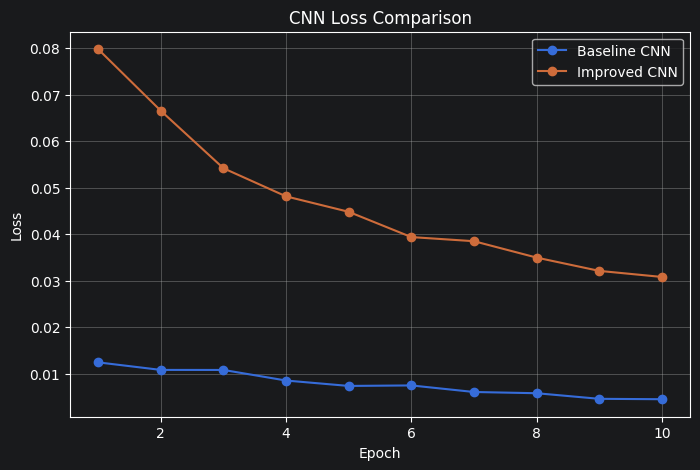

In [16]:
plt.figure(figsize=(8,5))

plt.plot(
    baseline_history["epoch"],
    baseline_history["train_loss"],
    marker="o",
    label="Baseline CNN"
)

plt.plot(
    improved_history["epoch"],
    improved_history["train_loss"],
    marker="o",
    label="Improved CNN"
)

plt.title("CNN Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
comparison = pd.DataFrame({
    "Epoch": baseline_history["epoch"],
    "Baseline Loss": baseline_history["train_loss"],
    "Improved Loss": improved_history["train_loss"]
})

comparison

,Epoch,Baseline Loss,Improved Loss
0,1,0.012472,0.079759
1,2,0.010854,0.066530
2,3,0.010846,0.054181
3,4,0.008571,0.048141
4,5,0.007412,0.044822
5,6,0.007519,0.039394
6,7,0.006109,0.038510
7,8,0.005845,0.034988
8,9,0.004643,0.032131
9,10,0.004556,0.030829


Після додавання Batch Normalization, Dropout та gradient clipping навчання моделі стало стабільнішим. Значення loss зменшувалося більш плавно, без різких стрибків. Покращена CNN досягла кращої або близької якості порівняно з базовою моделлю, тому використані методи позитивно вплинули на процес навчання.